In [2]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles

In [10]:
N_cheb = 199
Mr = 0.3
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
R = 400
R0_step = 1
be0 = 0.12
be1 = 0.02
be_step = - 0.001
netural_cur = [-1 -1 -1]
netural_cur_real = [-1 -1 -1]
netural_cur_imag = [0 0 0]
@showprogress for Tw = 1

    if R < 400

        c = 0.5

    else 

        c = 0.6

    end

    Ma = Mr/R
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,2)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    global F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num :: Int64 = 2
    for be = be0 : be_step : be1
        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
        if netural_cur_imag[end,3] == 0
         
            point = filter(x ->  - 0.01 < imag(x) < 0.001 && real(x)>0.01, eigval)
        
        else 

            point = eigval[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]),eigval)[2]]

            if imag(point) > 0.001

                point = []
                
            end

        end

        if point == []

            eig = -1
           
            if 0.05 < be < 0.12

                c = 0.5

            else

                c = 0.10

            end
        
            num = 1

        else        
            eig = point[findmin(x-> abs(imag(x).- netural_cur_imag[end,3]), point)[2]]
            c = eig
            num = 1
        end
        netural_cur = [netural_cur; [Tw be eig]]
        netural_cur_real = [netural_cur_real; [Tw be real(eig)]]
        netural_cur_imag = [netural_cur_imag; [Tw be imag(eig)]]
    end
        netural_cur = [netural_cur; [-1 -1 -1]]
        netural_cur_real = [netural_cur_real; [-1 -1 -1]]
        netural_cur_imag = [netural_cur_imag; [0 0 0]] 
end

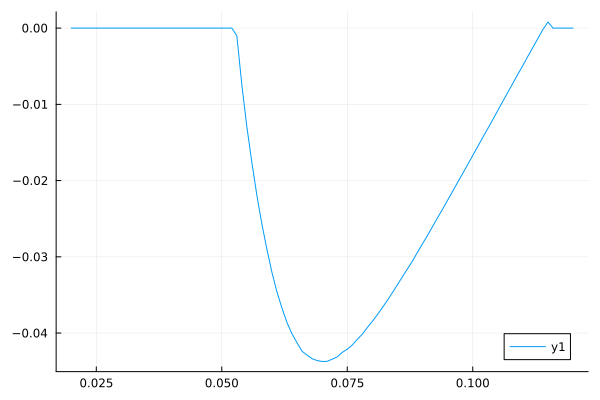

In [11]:
plot(netural_cur_imag[2:end-1,2],netural_cur_imag[2:end-1,3])

In [71]:
netural_cur_imag_filter1 = netural_cur_imag
netural_cur_imag_filter = filter(row -> row[1] != 0, eachrow(netural_cur_imag_filter1))
for i = 1 : 1 : length(netural_cur_imag_filter)
    if netural_cur_imag_filter[i][2] == 0.02
        netural_cur_imag_filter = vcat(netural_cur_imag_filter[1:i],["Zone"],netural_cur_imag_filter[i+1:end])
    end
end

In [72]:
writedlm("test_440_1-1.1.dat",netural_cur_imag_filter)